# Heart Disease Analysis

In [1]:
# !pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [2]:
# importing library for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




## Step 1 : Data Ingestion

In [3]:
# load the data to dataframe
df = X.join(y)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [4]:
# change the names of columns for understanding
# Using the variable information from heart_disease.variables
new_column_names = {
    'age': 'Age',
    'sex': 'Sex',
    'cp': 'ChestPainType',
    'trestbps': 'RestingBP',
    'chol': 'Cholesterol',
    'fbs': 'FastingBS',
    'restecg': 'RestingECG',
    'thalach': 'MaxHR',
    'exang': 'ExerciseAngina',
    'oldpeak': 'STdepression',
    'slope': 'STslope',
    'ca': 'NumMajorVessels',
    'thal': 'Thalassemia',
    'num': 'HeartDisease'
}

df = df.rename(columns=new_column_names)

# Display the first few rows with new column names
df.head()

# Print descriptions for better understanding
print("\n--- Feature Descriptions ---")
print("Age: Age in years")
print("Sex: Sex (1 = male; 0 = female)")
print("ChestPainType: Chest pain type (1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic)")
print("RestingBP: Resting blood pressure (in mm Hg on admission to the hospital)")
print("Cholesterol: Serum cholestoral in mg/dl")
print("FastingBS: Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)")
print("RestingECG: Resting electrocardiographic results (0: normal, 1: ST-T wave abnormality, 2: left ventricular hypertrophy)")
print("MaxHR: Maximum heart rate achieved")
print("ExerciseAngina: Exercise induced angina (1 = yes; 0 = no)")
print("STdepression: ST depression induced by exercise relative to rest")
print("STslope: The slope of the peak exercise ST segment (1: upsloping, 2: flat, 3: downsloping)")
print("NumMajorVessels: Number of major vessels (0-3) colored by fluoroscopy")
print("Thalassemia: Thalassemia (3: normal, 6: fixed defect, 7: reversable defect)")
print("HeartDisease: Diagnosis of heart disease (angiographic disease status: 0: < 50% diameter narrowing, 1-4: > 50% diameter narrowing)")



--- Feature Descriptions ---
Age: Age in years
Sex: Sex (1 = male; 0 = female)
ChestPainType: Chest pain type (1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic)
RestingBP: Resting blood pressure (in mm Hg on admission to the hospital)
Cholesterol: Serum cholestoral in mg/dl
FastingBS: Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
RestingECG: Resting electrocardiographic results (0: normal, 1: ST-T wave abnormality, 2: left ventricular hypertrophy)
MaxHR: Maximum heart rate achieved
ExerciseAngina: Exercise induced angina (1 = yes; 0 = no)
STdepression: ST depression induced by exercise relative to rest
STslope: The slope of the peak exercise ST segment (1: upsloping, 2: flat, 3: downsloping)
NumMajorVessels: Number of major vessels (0-3) colored by fluoroscopy
Thalassemia: Thalassemia (3: normal, 6: fixed defect, 7: reversable defect)
HeartDisease: Diagnosis of heart disease (angiographic disease status: 0: < 50% diameter narrowing, 1-4: > 50% diamet

In [5]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,STdepression,STslope,NumMajorVessels,Thalassemia,HeartDisease
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [6]:
df.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,STdepression,STslope,NumMajorVessels,Thalassemia,HeartDisease
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


## Step 2 : Data Cleaning

In [7]:
# null count
df.isnull().sum()

Age                0
Sex                0
ChestPainType      0
RestingBP          0
Cholesterol        0
FastingBS          0
RestingECG         0
MaxHR              0
ExerciseAngina     0
STdepression       0
STslope            0
NumMajorVessels    4
Thalassemia        2
HeartDisease       0
dtype: int64

In [8]:
## where data is missing
df[df.isnull().any(axis=1)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,STdepression,STslope,NumMajorVessels,Thalassemia,HeartDisease
87,53,0,3,128,216,0,2,115,0,0.0,1,0.0,NaN,0
166,52,1,3,138,223,0,0,169,0,0.0,1,NaN,3.0,0
192,43,1,4,132,247,1,2,143,1,0.1,2,NaN,7.0,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0.0,NaN,2
287,58,1,2,125,220,0,0,144,0,0.4,2,NaN,7.0,0
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0,0


In [9]:
# see the value_counts of missing data columns
df.NumMajorVessels.value_counts()


NumMajorVessels
0.0    176
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64

In [10]:
df.Thalassemia.value_counts()

Thalassemia
3.0    166
7.0    117
6.0     18
Name: count, dtype: int64

In [11]:
# iloc the missing values and fill it
df.iloc[df[df.NumMajorVessels.isnull()].index]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,STdepression,STslope,NumMajorVessels,Thalassemia,HeartDisease
166,52,1,3,138,223,0,0,169,0,0.0,1,NaN,3.0,0
192,43,1,4,132,247,1,2,143,1,0.1,2,NaN,7.0,1
287,58,1,2,125,220,0,0,144,0,0.4,2,NaN,7.0,0
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0,0


In [12]:
# Fill null data with mode using a loop and fillna
for col in ["NumMajorVessels", "Thalassemia"]:
    df[col] = df[col].fillna(df[col].mode().iloc[0])

# Verify that all null values have been filled
df.isnull().sum()

Age                0
Sex                0
ChestPainType      0
RestingBP          0
Cholesterol        0
FastingBS          0
RestingECG         0
MaxHR              0
ExerciseAngina     0
STdepression       0
STslope            0
NumMajorVessels    0
Thalassemia        0
HeartDisease       0
dtype: int64

## Step 4 : Feature Engineering

In [13]:
# split the data into X and y
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [14]:
# split it into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#shape
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(242, 13) (61, 13) (242,) (61,)


In [15]:
# scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [16]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)
X_train.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,STdepression,STslope,NumMajorVessels,Thalassemia
count,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,242.000000,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02,2.420000e+02
mean,2.569111e-17,-8.074349e-17,6.789794e-17,-6.165867e-16,2.770970e-16,3.027881e-17,0.000000,4.477594e-16,1.064346e-16,-4.037175e-17,-5.505238e-18,6.973302e-17,1.468064e-17
std,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00,1.002073e+00
min,-2.838504e+00,-1.384075e+00,-2.117322e+00,-2.107124e+00,-2.483637e+00,-3.973597e-01,-0.995893,-3.527356e+00,-7.158911e-01,-8.735730e-01,-9.634316e-01,-7.158685e-01,-8.691608e-01
25%,-7.486013e-01,-1.384075e+00,-1.104690e+00,-6.762991e-01,-6.980404e-01,-3.973597e-01,-0.995893,-6.287399e-01,-7.158911e-01,-8.735730e-01,-9.634316e-01,-7.158685e-01,-8.691608e-01
50%,1.313575e-01,7.225044e-01,-9.205746e-02,-1.259817e-01,-1.166833e-01,-3.973597e-01,-0.493797,1.070627e-01,-7.158911e-01,-2.408775e-01,6.556688e-01,-7.158685e-01,-8.691608e-01
75%,7.638279e-01,7.225044e-01,9.205746e-01,4.243356e-01,5.581063e-01,-3.973597e-01,1.012492,7.425285e-01,1.396861e+00,4.761775e-01,6.556688e-01,4.018101e-01,1.208241e+00
max,2.441249e+00,7.225044e-01,9.205746e-01,3.726240e+00,3.558325e+00,2.516611e+00,1.012492,2.314470e+00,1.396861e+00,4.356710e+00,2.274769e+00,2.637167e+00,1.208241e+00


## Step 5 : Machine Learning

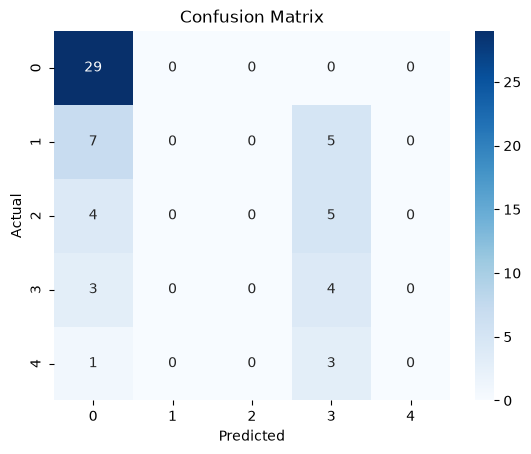


Classification Report:
               precision    recall  f1-score   support

           0       0.66      1.00      0.79        29
           1       0.00      0.00      0.00        12
           2       0.00      0.00      0.00         9
           3       0.24      0.57      0.33         7
           4       0.00      0.00      0.00         4

    accuracy                           0.54        61
   macro avg       0.18      0.31      0.23        61
weighted avg       0.34      0.54      0.42        61


Accuracy: 0.5409836065573771


/Users/shubhamkeshari/Desktop/project/python/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shubhamkeshari/Desktop/project/python/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shubhamkeshari/Desktop/project/python/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [17]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(max_depth=2)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# classification report
cr = classification_report(y_test, dt_pred)
print("\nClassification Report:\n", cr)
# accuracy
print("\nAccuracy:", accuracy_score(y_test, dt_pred))

#

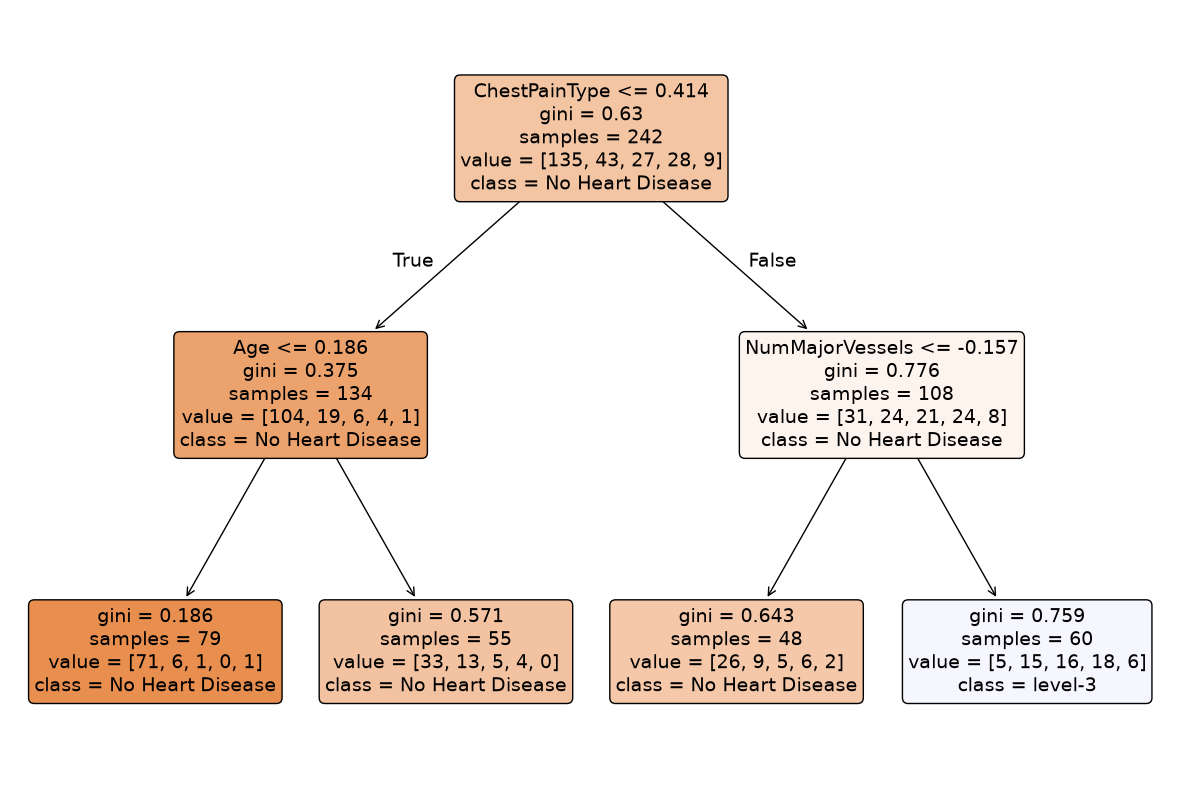

In [18]:
# plot the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No Heart Disease', 'Level-1', 'Level-2', 'level-3', 'Level-4'], filled=True, rounded=True)
plt.show()


y_binary  = df[''].apply(lambda)